## Long- Range CNOT gate teleportation using dyanic circuits

#### Step 1: Map the problem to circuits and operators

In [1]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.classical import expr

def get_dynamic_CNOT_circuit(num_qubit):
    """
    (1) 1D Chain of nearest neighbors
    (2) 0th qubit is the control and the last qubit is the target
    (3) The control qubit starts in the positive state
    """

    num_ancilla = num_qubit - 2
    num_ancilla_pair = int(num_ancilla / 2)

    qr = QuantumRegister(num_qubit)
    cr1 = ClassicalRegister(num_ancilla_pair, name='cr1') #The parity controlled X gate
    cr2 = ClassicalRegister(num_ancilla - num_ancilla_pair, name='cr2') #The parity controlled Z gate
    cr3 = ClassicalRegister(2, name='cr3') # The final measurement on the control and target qubit
    qc = QuantumCircuit(qr, cr1, cr2, cr3)

    #Initialize the control qubit
    qc.h(0)
    qc.barrier()

    #Entagle the control qubit with the ancilla qubits
    qc.cx(0, 1)

    #Create Bell pairs on the ancilla qubits
    #The first ancilla qubit in index 1
    for i in range(num_ancilla_pair):
        qc.h(2+2*i)
        qc.cx(2+2*i, 2+2*i + 1)

    #Prepare Bell pairs on staggered ancilla and data qubits
    for i in range(num_ancilla_pair + 1):
        qc.cx(1+2*i, 1+2*i+1)
    for i in range(1, num_ancilla_pair+2):
        qc.h(2*i-1)

    #Measurement on altering ancilla qubits starting with the first one
    # Keep track of the parity for eventual conditional Z gate
    for i in range(1, num_ancilla_pair + 2):
        qc.measure(2*i - 1, cr2[i-1])
        if i == 1:
            parity_control = expr.lift(cr2[i-1])
        else:
            parity_control = expr.bit_xor(cr2[i-1], parity_control)  

    #Measurement on staggered alternating ancilla qubits starting with the second one  
    #Keep track of the parity for eventual conditional X gate
    for i in range(num_ancilla_pair):
        qc.measure(2*i + 2, cr1[i])
        if i == 0:
            parity_target = expr.lift(cr1[i])
        else:
            parity_target = expr.bit_xor(cr1[i], parity_target)   
    
    with qc.if_test(parity_control):
        qc.z(0)

    with qc.if_test(parity_target):
        qc.x(-1)

    return qc                        

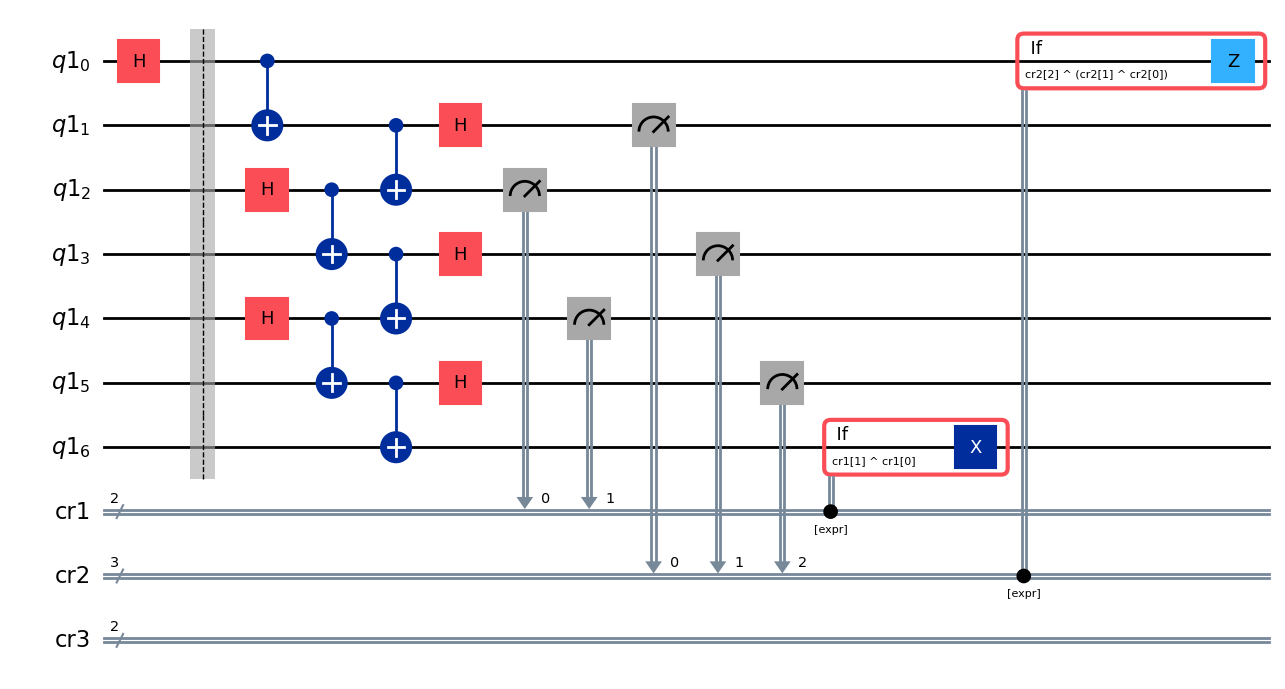

In [3]:
qc = get_dynamic_CNOT_circuit(num_qubit=7)
qc.draw('mpl')

In [4]:
max_num_qubit =  41

qc_list = []
num_qubit_list = list(range(7, max_num_qubit + 1, 2))

for num_qubit in num_qubit_list:
    qc_list.append(get_dynamic_CNOT_circuit(num_qubit=num_qubit))

#### Step 2: Optimize the problem for quantum execution

In [6]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService

backend_name = 'ibm_brisbane'
service = QiskitRuntimeService()
backend = service.backend(backend_name)
pm = generate_preset_passmanager(backend=backend, optimization_level=1)
print("Done getting backend")

qc_transpiled_list = pm.run(qc_list)


management.get:WARNING:2025-10-27 08:10:13,553: Loading default saved account


IBMInputValueError: 'The given API token is associated with an account that does not have access to the instance crn:v1:bluemix:public:quantum-computing:us-east:a/8c4d15a56d1342d9818d743c3da92211:1a53b5a6-1d53-49aa-b862-7e3f86a869eb::. To use this instance, use an API token generated from the account with this instance available.'